In [28]:
# Import packages
import pandas as pd
from matplotlib import pyplot as plt

In [29]:
# Read the housing.csv
housing_df = pd.read_csv("housing.csv")
housing_df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [30]:
# 1. How many geographical units are there in the dataset?
number_of_unique_geo_units = housing_df[["longitude","latitude"]].drop_duplicates().shape[0]
display(number_of_unique_geo_units)

12590

In [31]:
# 2. What is the mean house value among all "Ocean_proximity" categories?
total_mean_median = housing_df["median_house_value"].mean()
int(round(total_mean_median, 0))

206856

In [32]:
# 3. What is the mean house value in each “Ocean_proximity” category
mean_median_per_proximity = housing_df.groupby("ocean_proximity")["median_house_value"].mean()
round(mean_median_per_proximity,0)

ocean_proximity
<1H OCEAN     240084.0
INLAND        124805.0
ISLAND        380440.0
NEAR BAY      259212.0
NEAR OCEAN    249434.0
Name: median_house_value, dtype: float64

In [33]:
# 4. What can you tell about the differences between the mean and median values
#“Ocean_proximity” categories?
median_among_median_values_per_group = housing_df.groupby("ocean_proximity")["median_house_value"].median()
new_df =  (mean_median_per_proximity - median_among_median_values_per_group).round(0).to_frame("mean_vs_median")
def interpret_difference(value):
    if value < 0:
        return "Lower-valued units pull the mean downward"
    elif value > 0:
        return "Higher-valued units pull the mean upward"
    else:
        return "Mean and median are equal"
new_df["interpretation"] = (
    new_df["mean_vs_median"].apply(interpret_difference)
)
display(new_df)


,mean_vs_median,interpretation
ocean_proximity,,
<1H OCEAN,25234.0,Higher-valued units pull the mean upward
INLAND,16305.0,Higher-valued units pull the mean upward
ISLAND,-34260.0,Lower-valued units pull the mean downward
NEAR BAY,25412.0,Higher-valued units pull the mean upward
NEAR OCEAN,19984.0,Higher-valued units pull the mean upward


Maximum median housing age:  52.0
Maximum median_house_value:  500001.0


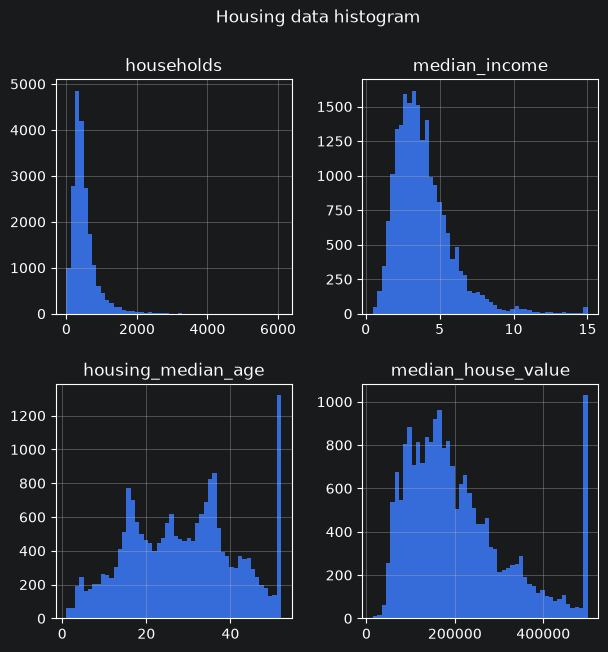

In [34]:
# 5.Create a histogram for “households”, “median_income”, “housing_median_age” and “median_house_value”. Set higher bin value to see more details
# 6. Looking at the histograms, and the data, we can assume that the age is capped at around 50 and the maximum median value is around 500 000.
housing_df[["households","median_income", "housing_median_age", "median_house_value"]].hist(bins=50, figsize=(7,7))
print("Maximum median housing age: ", housing_df["housing_median_age"].max())
print("Maximum median_house_value: ",housing_df["median_house_value"].max())
plt.suptitle("Housing data histogram")
plt.show()


In [35]:
# 7. In which category are the most expensive and the largest houses typically located? In which category are the least expensive and smallest houses typically located?
## Most expensive:
print("Typically most expensive ocean proximity category:", housing_df.groupby("ocean_proximity")["median_house_value"].mean().nlargest(1).to_dict())
## Largest houses:
print("Typically largest houses in ocean proximity category:", housing_df.groupby("ocean_proximity")["total_rooms"].mean().nlargest(1).to_dict())
## Least expensive:
print("Typically cheapest ocean proximity category:", housing_df.groupby("ocean_proximity")["median_house_value"].mean().nsmallest(1).to_dict())
## Smallest houses:
print("Typically smallest houses in ocean proximity category:", housing_df.groupby("ocean_proximity")["total_rooms"].mean().nsmallest(1).to_dict())

# Interesting, that Inland has the Largest houses but also the cheapest ones, and the Island category has the most expensive but also the smallest houses




Typically most expensive ocean proximity category: {'ISLAND': 380440.0}
Typically largest houses in ocean proximity category: {'INLAND': 2717.7427873607085}
Typically cheapest ocean proximity category: {'INLAND': 124805.39200122119}
Typically smallest houses in ocean proximity category: {'ISLAND': 1574.6}


In [36]:
# 8. What can you tell about the quality of the houses in each "Ocean_proximity" category? (e.g., the age of the houses, the number of rooms)
housing_df.groupby("ocean_proximity")[["median_house_value", "housing_median_age", "total_rooms", "total_bedrooms"]].mean()
# Inland has typically the most room, but the <1H Ocean has typically the most bedrooms
# The oldest houses are on the Island, and the newest houses are Inland

,median_house_value,housing_median_age,total_rooms,total_bedrooms
ocean_proximity,,,,
<1H OCEAN,240084.285464,29.279225,2628.343586,546.539185
INLAND,124805.392001,24.271867,2717.742787,533.881619
ISLAND,380440.000000,42.400000,1574.600000,420.400000
NEAR BAY,259212.311790,37.730131,2493.589520,514.182819
NEAR OCEAN,249433.977427,29.347254,2583.700903,538.615677


In [37]:
# 9. What can you tell about the demographic living in each “Ocean_proximity” category? (e.g., population, households, median income)
display(housing_df.groupby("ocean_proximity")[["population", "median_income", "households",]].mean())
# People in the <1H Ocean have the highest mean median_income, it also has the highest mean households
# The island has the least population and households.

,population,median_income,households
ocean_proximity,,,
<1H OCEAN,1520.290499,4.230682,517.744965
INLAND,1391.046252,3.208996,477.447565
ISLAND,668.000000,2.744420,276.600000
NEAR BAY,1230.317467,4.172885,488.616157
NEAR OCEAN,1354.008653,4.005785,501.244545


In [38]:
# 10. Are there any other interesting observations and questions you can come up with regarding this dataset?
# What ocean_proximity has the most population per household
housing_df["pop_per_household"] = housing_df["population"] / housing_df["households"]
print("Ocean proximity with the most population per household: ", housing_df.groupby("ocean_proximity")["pop_per_household"].mean().nlargest(1).to_dict())
# What is the maximum pop_per_household?
print("The maximum population per household observed is: ",housing_df["pop_per_household"].max())
# The maximum value seems a bit much lets check the data for the outlier
display(housing_df.sort_values("pop_per_household", ascending=False).head(15))


Ocean proximity with the most population per household:  {'INLAND': 3.3029543586884675}
The maximum population per household observed is:  1243.3333333333333


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,pop_per_household
19006,-121.98,38.32,45.0,19.0,5.0,7460.0,6.0,10.2264,137500.0,INLAND,1243.333333
3364,-120.51,40.41,36.0,36.0,8.0,4198.0,7.0,5.5179,67500.0,INLAND,599.714286
16669,-120.70,35.32,46.0,118.0,17.0,6532.0,13.0,4.2639,350000.0,NEAR OCEAN,502.461538
13034,-121.15,38.69,52.0,240.0,44.0,6675.0,29.0,6.1359,225000.0,INLAND,230.172414
9172,-118.59,34.47,5.0,538.0,98.0,8733.0,105.0,4.2391,154600.0,INLAND,83.171429
12104,-117.33,33.97,8.0,152.0,19.0,1275.0,20.0,1.6250,162500.0,INLAND,63.750000
16420,-121.29,37.89,26.0,161.0,27.0,1542.0,30.0,5.7485,162500.0,INLAND,51.400000
8874,-118.45,34.06,52.0,204.0,34.0,1154.0,28.0,9.3370,500001.0,<1H OCEAN,41.214286
13366,-117.63,33.94,36.0,447.0,95.0,2886.0,85.0,4.2578,183300.0,INLAND,33.952941
5986,-117.71,34.10,52.0,567.0,152.0,2688.0,126.0,1.8750,212500.0,INLAND,21.333333


In [39]:
# Given that the median_income in the area with population 7460 and 6 households, lets check for any outliers in the median income
display(housing_df["median_income"].describe())
display(housing_df.sort_values("median_income", ascending=False).head(20))
# Do high median_income houses also have the most expensive median_houses?
# It seems like the median income is also capped at 15.0001

count    20640.000000
mean         3.870671
std          1.899822
min          0.499900
25%          2.563400
50%          3.534800
75%          4.743250
max         15.000100
Name: median_income, dtype: float64

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,pop_per_household
8851,-118.42,34.09,40.0,3552.0,392.0,1024.0,370.0,15.0001,500001.0,<1H OCEAN,2.767568
8850,-118.41,34.09,37.0,2716.0,302.0,809.0,291.0,15.0001,500001.0,<1H OCEAN,2.780069
8849,-118.40,34.08,52.0,3815.0,439.0,1266.0,413.0,15.0001,500001.0,<1H OCEAN,3.065375
8848,-118.39,34.08,52.0,3759.0,464.0,1407.0,422.0,15.0001,500001.0,<1H OCEAN,3.334123
8852,-118.42,34.08,48.0,2413.0,261.0,770.0,248.0,15.0001,500001.0,<1H OCEAN,3.104839
15241,-117.23,32.99,17.0,2718.0,326.0,1011.0,319.0,15.0001,500001.0,NEAR OCEAN,3.169279
8878,-118.50,34.04,52.0,3000.0,374.0,1143.0,375.0,15.0001,500001.0,<1H OCEAN,3.048000
8805,-118.34,33.76,34.0,5586.0,674.0,1871.0,636.0,15.0001,500001.0,NEAR OCEAN,2.941824
8847,-118.40,34.09,45.0,2686.0,283.0,857.0,259.0,15.0001,500001.0,<1H OCEAN,3.308880
16910,-122.36,37.56,32.0,4684.0,540.0,1512.0,511.0,15.0001,500001.0,NEAR OCEAN,2.958904


In [40]:
#Another question, what is the standard deviation for the median income in the ocean_proximity
display(housing_df.groupby("ocean_proximity")["median_income"].describe())

,count,mean,std,min,25%,50%,75%,max
ocean_proximity,,,,,,,,
<1H OCEAN,9136.0,4.230682,2.001223,0.4999,2.864900,3.87500,5.180500,15.0001
INLAND,6551.0,3.208996,1.437465,0.4999,2.188950,2.98770,3.961500,15.0001
ISLAND,5.0,2.744420,0.444180,2.1579,2.604200,2.73610,2.833300,3.3906
NEAR BAY,2290.0,4.172885,2.017427,0.4999,2.834750,3.81865,5.054425,15.0001
NEAR OCEAN,2658.0,4.005785,2.010558,0.5360,2.630525,3.64705,4.837400,15.0001


In [43]:
# Lets also check the correlation between median income and median house value, we should disregard the correlation for Island since the sample is only 5 observations
display(housing_df[housing_df["ocean_proximity"] != "ISLAND"].groupby("ocean_proximity")[["median_income","median_house_value"]].corr().sort_values("median_income", ascending=True))
# The correlation is moderately positive (0.5-0.7), high positive (0.7-0.9) based on the rule of thumb https://pmc.ncbi.nlm.nih.gov/articles/PMC3576830/table/T1/

,,median_income,median_house_value
ocean_proximity,,,
NEAR BAY,median_house_value,0.633208,1.000000
<1H OCEAN,median_house_value,0.679041,1.000000
INLAND,median_house_value,0.699267,1.000000
NEAR OCEAN,median_house_value,0.703787,1.000000
INLAND,median_income,1.000000,0.699267
<1H OCEAN,median_income,1.000000,0.679041
NEAR BAY,median_income,1.000000,0.633208
NEAR OCEAN,median_income,1.000000,0.703787
